<a href="https://colab.research.google.com/github/yeji79/BioBigData/blob/main/Notebooks/ML_practice_11_cifar10_masked_image_reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <font color=blue> 바이오 빅데이터 분석 (5B)</font>

### 실습 주제: CIFAR-10과 Transformer를 이용한 Masked Image Reconstruction

이 노트북에서는 CIFAR-10 이미지를 작은 패치(patch)로 나눈 뒤 일부 패치를 가리고, Transformer encoder가 가려진 영역의 원래 픽셀을 복원하도록 학습합니다. 이는 BERT의 masked language modeling을 이미지에 적용한 **masked image modeling**의 간단한 형태입니다.

### 학습 목표
1. CIFAR-10 데이터를 불러오고 이미지의 특징을 확인한다.
2. 이미지를 패치 토큰으로 변환하고 무작위로 일부 패치를 가린다.
3. self-attention을 사용하는 작은 Vision Transformer를 구현한다.
4. 정답 label 없이 이미지 자체를 정답으로 사용하는 self-supervised 학습을 수행한다.
5. 원본 이미지, masked image, reconstruction을 나란히 비교한다.

#### Machine Learning and Bioinformatics (MLBI) Lab

### 실습 절차

1. 실습 환경과 재현성 설정
2. CIFAR-10 데이터 불러오기
3. 원본 이미지 확인
4. 이미지 patchify / unpatchify
5. 무작위 patch masking
6. Tiny Masked Image Transformer 구성
7. masked patch만 대상으로 모델 학습
8. 학습 곡선 및 복원 결과 확인
9. 모델 저장과 추가 실험

### 0. 실습 환경

필요 패키지는 `tensorflow`, `numpy`, `matplotlib`입니다. CIFAR-10은 처음 실행할 때 한 번 자동으로 다운로드됩니다.

GPU가 없어도 실행할 수 있도록 작은 모델과 부분 데이터 설정을 기본값으로 사용합니다. 빠른 동작 확인은 `QUICK_RUN=True`, 더 나은 복원 결과는 `QUICK_RUN=False`로 실행하세요.

In [11]:
# 필요한 경우에만 주석을 풀어 실행하세요.
!pip install tensorflow matplotlib

In [12]:
import os
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.keras.utils.set_random_seed(RANDOM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


### 1. 로컬 CIFAR-10 데이터 불러오기

CIFAR-10은 32×32 RGB 이미지 60,000장과 10개 class로 구성되어 있습니다. 이 실습의 학습 목표는 분류가 아니라 **가려진 픽셀 복원**이므로 class label은 시각화에만 사용합니다.

이 노트북은 인터넷에서 데이터를 다운로드하지 않고, 노트북과 같은 위치의 `cifar-10-python/cifar-10-batches-py` 폴더에서 Python batch 파일을 직접 읽습니다. 픽셀값은 `[0, 255]`에서 `[0, 1]` 범위로 정규화합니다.

In [13]:
import pickle

CIFAR_DIR = Path("cifar-10-batches-py")

required_files = [
    *(CIFAR_DIR / f"data_batch_{i}" for i in range(1, 6)),
    CIFAR_DIR / "test_batch",
]
missing_files = [str(path) for path in required_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "CIFAR-10 batch 파일을 찾을 수 없습니다. "
        "노트북 실행 위치와 cifar-10-python 폴더 위치를 확인하세요.\n"
        + "\n".join(missing_files)
    )


def load_cifar_batch(path):
    # CIFAR-10 Python 배포본은 bytes key를 갖는 pickle 형식입니다.
    with path.open("rb") as file:
        batch = pickle.load(file, encoding="bytes")

    images = batch[b"data"]
    labels = np.asarray(batch[b"labels"], dtype=np.int64)

    # 저장 형태 (N, 3072) = RGB channel별 32x32를 이미지 형태로 변환합니다.
    images = images.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return images, labels


train_batches = [load_cifar_batch(CIFAR_DIR / f"data_batch_{i}") for i in range(1, 6)]
x_train = np.concatenate([images for images, _ in train_batches], axis=0)
y_train = np.concatenate([labels for _, labels in train_batches], axis=0)
x_test, y_test = load_cifar_batch(CIFAR_DIR / "test_batch")

# class 이름도 로컬 metadata에서 읽습니다.
meta_path = CIFAR_DIR / "batches.meta"
with meta_path.open("rb") as file:
    meta = pickle.load(file, encoding="bytes")
CLASS_NAMES = [name.decode("utf-8") for name in meta[b"label_names"]]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("data directory:", CIFAR_DIR.resolve())
print("classes:", CLASS_NAMES)
print("train:", x_train.shape, y_train.shape)
print("test :", x_test.shape, y_test.shape)
print("pixel range:", x_train.min(), "~", x_train.max())

data directory: /content/cifar-10-batches-py
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
train: (50000, 32, 32, 3) (50000,)
test : (10000, 32, 32, 3) (10000,)
pixel range: 0.0 ~ 1.0


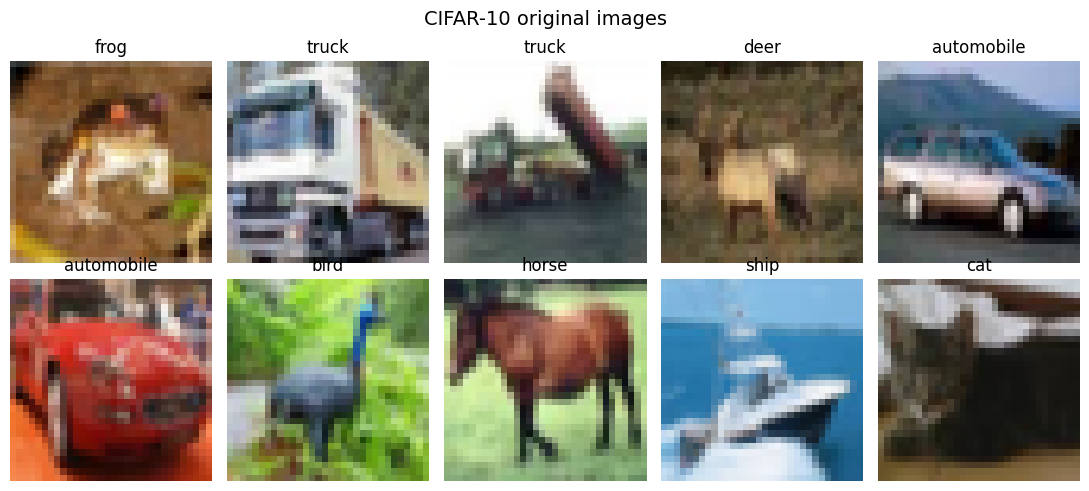

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for ax, image, label in zip(axes.flat, x_train[:10], y_train[:10]):
    ax.imshow(image)
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")
plt.suptitle("CIFAR-10 original images", fontsize=14)
plt.tight_layout()
plt.show()

### 2. 이미지를 patch token으로 바꾸기

Transformer는 원래 token sequence를 입력으로 받습니다. 따라서 32×32 이미지를 겹치지 않는 4×4 patch로 자릅니다.

- patch 크기: 4×4×3 = 48개 픽셀값
- 가로/세로 patch 수: 32 / 4 = 8
- 전체 token 수: 8×8 = 64

`patchify`는 이미지를 64개의 vector로 바꾸고, `unpatchify`는 이를 다시 이미지로 조립합니다.

In [15]:
IMAGE_SIZE = 32
CHANNELS = 3
PATCH_SIZE = 4
GRID_SIZE = IMAGE_SIZE // PATCH_SIZE
NUM_PATCHES = GRID_SIZE ** 2
PATCH_DIM = PATCH_SIZE * PATCH_SIZE * CHANNELS

def patchify(images):
    # (B, 32, 32, 3) -> (B, 64, 48)
    patches = tf.image.extract_patches(
        images=images,
        sizes=[1, PATCH_SIZE, PATCH_SIZE, 1],
        strides=[1, PATCH_SIZE, PATCH_SIZE, 1],
        rates=[1, 1, 1, 1],
        padding="VALID",
    )
    return tf.reshape(patches, [-1, NUM_PATCHES, PATCH_DIM])

def unpatchify(patches):
    # (B, 64, 48) -> (B, 32, 32, 3)
    batch_size = tf.shape(patches)[0]
    x = tf.reshape(
        patches,
        [batch_size, GRID_SIZE, GRID_SIZE, PATCH_SIZE, PATCH_SIZE, CHANNELS],
    )
    x = tf.transpose(x, [0, 1, 3, 2, 4, 5])
    return tf.reshape(x, [batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS])

sample = tf.convert_to_tensor(x_train[:2])
round_trip = unpatchify(patchify(sample))
print("patch shape:", patchify(sample).shape)
print("maximum round-trip error:", float(tf.reduce_max(tf.abs(sample - round_trip))))

patch shape: (2, 64, 48)
maximum round-trip error: 0.0


### 3. 무작위 patch masking

각 이미지에서 `MASK_RATIO` 비율의 patch를 선택해 회색으로 가립니다. 학습 시에는 어떤 patch가 가려졌는지를 나타내는 boolean mask도 함께 모델에 전달합니다.

아래 예시는 같은 이미지에 서로 다른 무작위 mask가 적용될 수 있음을 보여줍니다.

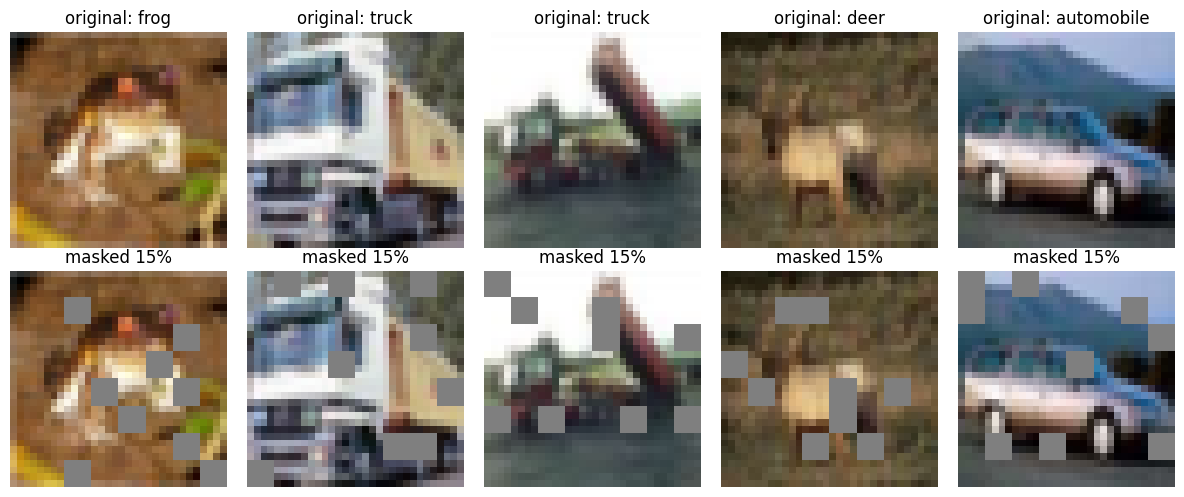

In [16]:
MASK_RATIO = 0.15
NUM_MASKED = int(NUM_PATCHES * MASK_RATIO)

def make_random_masks(batch_size, seed=None):
    # 각 sample에서 정확히 NUM_MASKED개의 patch를 True로 선택합니다.
    scores = tf.random.uniform([batch_size, NUM_PATCHES], seed=seed)
    selected = tf.argsort(scores, axis=1)[:, :NUM_MASKED]
    return tf.reduce_any(
        tf.one_hot(
            selected, depth=NUM_PATCHES,
            on_value=True, off_value=False, dtype=tf.bool
        ),
        axis=1,
    )

def apply_patch_mask(images, masks, fill_value=0.5):
    patches = patchify(images)
    fill = tf.fill(tf.shape(patches), tf.cast(fill_value, patches.dtype))
    masked_patches = tf.where(masks[..., None], fill, patches)
    return unpatchify(masked_patches)

example_images = tf.convert_to_tensor(x_train[:5])
example_masks = make_random_masks(5, seed=RANDOM_SEED)
example_masked = apply_patch_mask(example_images, example_masks)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(5):
    axes[0, i].imshow(example_images[i])
    axes[0, i].set_title(f"original: {CLASS_NAMES[y_train[i]]}")
    axes[1, i].imshow(example_masked[i])
    axes[1, i].set_title(f"masked {MASK_RATIO:.0%}")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

### 4. 학습용 `tf.data` 만들기

모델 입력은 `(원본 이미지, mask)`입니다. 모델 내부에서 선택된 patch embedding을 학습 가능한 `[MASK]` token으로 교체합니다.

정답은 원본 patch이고, `sample_weight`는 masked patch에만 1을 부여합니다. 따라서 loss는 이미 보이는 patch가 아니라 **가린 patch의 복원 오차**만 계산합니다.

In [17]:
QUICK_RUN = False

if QUICK_RUN:
    TRAIN_SAMPLES = 10_000
    VAL_SAMPLES = 2_000
    BATCH_SIZE = 128
    EPOCHS = 10
else:
    TRAIN_SAMPLES = 45_000
    VAL_SAMPLES = 5_000
    BATCH_SIZE = 256
    EPOCHS = 10

def make_dataset(images, training):
    ds = tf.data.Dataset.from_tensor_slices(images)
    if training:
        ds = ds.shuffle(min(len(images), 10_000), seed=RANDOM_SEED)
    ds = ds.batch(BATCH_SIZE)

    def add_mask(batch_images):
        masks = make_random_masks(tf.shape(batch_images)[0])
        targets = patchify(batch_images)
        weights = tf.cast(masks, tf.float32)
        return (batch_images, masks), targets, weights

    ds = ds.map(add_mask, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(x_train[:TRAIN_SAMPLES], training=True)
val_ds = make_dataset(
    x_train[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES], training=False
)

(batch_images, batch_masks), batch_targets, batch_weights = next(iter(train_ds))
print("images :", batch_images.shape)
print("masks  :", batch_masks.shape)
print("targets:", batch_targets.shape)
print("masked patches per image:", int(tf.reduce_sum(batch_weights[0])))

images : (256, 32, 32, 3)
masks  : (256, 64)
targets: (256, 64, 48)
masked patches per image: 9


### 5. Tiny Masked Image Transformer

모델의 데이터 흐름은 다음과 같습니다.

`image → patch embedding → [MASK] token 치환 → positional embedding → Transformer blocks → patch pixel 예측`

Self-attention 덕분에 각 가려진 patch는 이미지의 모든 보이는 patch를 참고할 수 있습니다. 마지막 Dense layer는 각 token에서 4×4×3 픽셀값을 예측합니다.

In [18]:
class MaskToken(layers.Layer):
    def build(self, input_shape):
        embed_dim = input_shape[0][-1]
        self.mask_token = self.add_weight(
            name="mask_token",
            shape=(1, 1, embed_dim),
            initializer="random_normal",
            trainable=True,
        )

    def call(self, inputs):
        tokens, masks = inputs
        replacement = tf.broadcast_to(self.mask_token, tf.shape(tokens))
        return tf.where(masks[..., None], replacement, tokens)


def transformer_block(x, embed_dim, num_heads, mlp_dim, dropout):
    attention_input = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout,
    )(attention_input, attention_input)
    x = x + layers.Dropout(dropout)(attention_output)

    mlp_input = layers.LayerNormalization(epsilon=1e-6)(x)
    mlp_output = layers.Dense(mlp_dim, activation=tf.nn.gelu)(mlp_input)
    mlp_output = layers.Dropout(dropout)(mlp_output)
    mlp_output = layers.Dense(embed_dim)(mlp_output)
    return x + layers.Dropout(dropout)(mlp_output)


def build_masked_image_transformer(
    embed_dim=128, num_heads=4, depth=4, mlp_dim=256, dropout=0.1
):
    image_input = keras.Input((IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="image")
    mask_input = keras.Input((NUM_PATCHES,), dtype=tf.bool, name="patch_mask")

    # Conv2D의 kernel/stride를 patch 크기로 두면 patchify + linear projection과 같습니다.
    x = layers.Conv2D(
        embed_dim, kernel_size=PATCH_SIZE, strides=PATCH_SIZE, name="patch_projection"
    )(image_input)
    x = layers.Reshape((NUM_PATCHES, embed_dim))(x)
    x = MaskToken(name="mask_token")([x, mask_input])

    positions = tf.range(NUM_PATCHES)
    position_embedding = layers.Embedding(NUM_PATCHES, embed_dim, name="position_embedding")
    x = x + position_embedding(positions)

    for _ in range(depth):
        x = transformer_block(x, embed_dim, num_heads, mlp_dim, dropout)

    x = layers.LayerNormalization(epsilon=1e-6)(x)
    predicted_patches = layers.Dense(PATCH_DIM, activation="sigmoid", name="pixel_head")(x)
    return keras.Model([image_input, mask_input], predicted_patches, name="tiny_masked_vit")


model = build_masked_image_transformer()
model.summary()

Model: "tiny_masked_vit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_projection    │ (None, 8, 8, 128) │      6,272 │ image[0][0]       │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 64, 128)   │          0 │ patch_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_mask          │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask_token          │ (None, 64, 128)   │        128 │ reshape[0][0],    │
│ (MaskToken)         │                   │            │ patch_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 128)   │          0 │ mask_token[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 64, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 128)   │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64, 256)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64, 128)   │     32,896 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 64, 128)   │          0 │ add_1[0][0],      │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 64, 128)   │          0 │ add_2[0][0],    

 Total params: 542,768 (2.07 MB)

 Trainable params: 542,768 (2.07 MB)

 Non-trainable params: 0 (0.00 B)

### 6. 모델 학습

손실 함수는 mean squared error(MSE)입니다. 앞에서 만든 `sample_weight`에 의해 masked patch만 loss에 기여합니다.

- `EarlyStopping`: validation loss가 더 좋아지지 않으면 학습을 멈추고 최적 weight를 복원합니다.
- `ReduceLROnPlateau`: validation loss가 정체되면 learning rate를 낮춥니다.

`QUICK_RUN=True`는 구조 확인용이므로 결과가 다소 흐릴 수 있습니다. 선명한 결과를 원하면 전체 데이터로 30~50 epoch 정도 학습해 보세요.

In [19]:
model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=keras.losses.MeanSquaredError(),
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=6, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 800s 4s/step - loss: 0.0078 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 775s 4s/step - loss: 0.0063 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 770s 4s/step - loss: 0.0056 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 768s 4s/step - loss: 0.0054 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 785s 4s/step - loss: 0.0052 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 802s 4s/step - loss: 0.0050 - val_loss: 0.0045 - learning_rate: 0.0010
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 822s 4s/step - loss: 0.0047 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 755s 4s/step - loss: 0.0043 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 799s 4s/step - loss: 0.0039 - val_loss: 0.0036 - learning_rate: 0.0010
E

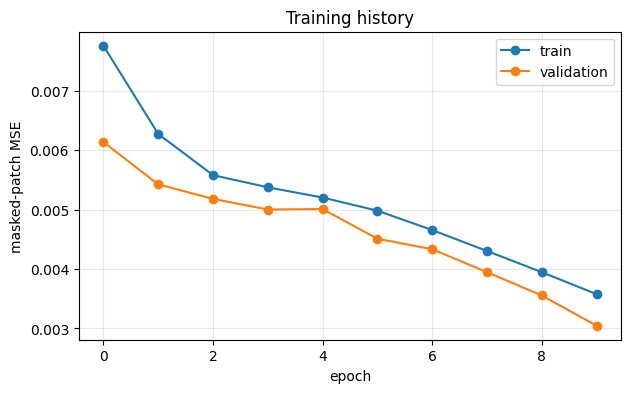

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], marker="o", label="train")
plt.plot(history.history["val_loss"], marker="o", label="validation")
plt.xlabel("epoch")
plt.ylabel("masked-patch MSE")
plt.title("Training history")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 7. Reconstruction 이미지 만들기

모델은 모든 patch를 예측하지만, 최종 reconstruction에서는 **보이는 patch는 원본을 유지하고 가린 patch만 모델 예측으로 채웁니다**. 이렇게 하면 가려진 영역에서 모델이 무엇을 추론했는지 명확히 볼 수 있습니다.

In [21]:
def reconstruct_images(model, images, masks):
    images = tf.convert_to_tensor(images, dtype=tf.float32)
    masks = tf.convert_to_tensor(masks, dtype=tf.bool)
    original_patches = patchify(images)
    predicted_patches = model.predict([images, masks], verbose=0)
    combined = tf.where(masks[..., None], predicted_patches, original_patches)
    return tf.clip_by_value(unpatchify(combined), 0.0, 1.0)


# test set에서 학습에 사용하지 않은 이미지 두 장을 선택합니다.
show_indices = [3, 17]
originals = tf.convert_to_tensor(x_test[show_indices])
show_masks = make_random_masks(len(show_indices), seed=123)
masked_images = apply_patch_mask(originals, show_masks)
reconstructions = reconstruct_images(model, originals, show_masks)

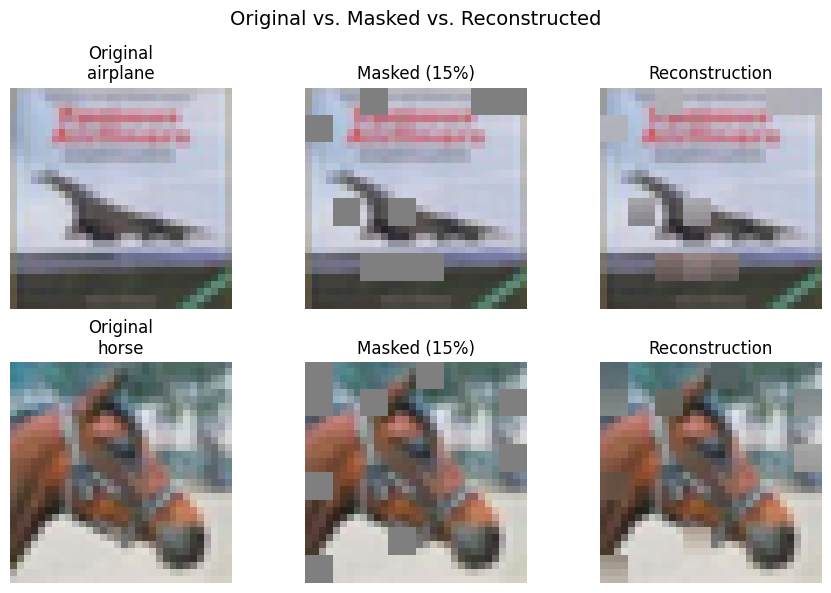

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for row, idx in enumerate(show_indices):
    axes[row, 0].imshow(originals[row])
    axes[row, 0].set_title(f"Original\n{CLASS_NAMES[y_test[idx]]}")
    axes[row, 1].imshow(masked_images[row])
    axes[row, 1].set_title(f"Masked ({MASK_RATIO:.0%})")
    axes[row, 2].imshow(reconstructions[row])
    axes[row, 2].set_title("Reconstruction")
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Original vs. Masked vs. Reconstructed", fontsize=14)
plt.tight_layout()
plt.show()

### 8. 원본과 reconstruction의 오차 확인

전체 이미지 MSE와 masked patch MSE를 따로 계산합니다. 보이는 patch는 원본을 그대로 사용했기 때문에 전체 이미지 MSE는 작게 보일 수 있습니다. 모델 자체의 복원 능력을 평가할 때는 **masked patch MSE**가 더 적절합니다.

In [23]:
def masked_patch_mse(originals, reconstructions, masks):
    squared_error = tf.reduce_mean(
        tf.square(patchify(originals) - patchify(reconstructions)), axis=-1
    )
    return tf.reduce_sum(squared_error * tf.cast(masks, tf.float32)) / tf.reduce_sum(
        tf.cast(masks, tf.float32)
    )

full_mse = tf.reduce_mean(tf.square(originals - reconstructions))
masked_mse = masked_patch_mse(originals, reconstructions, show_masks)
print(f"full-image MSE   : {float(full_mse):.6f}")
print(f"masked-patch MSE : {float(masked_mse):.6f}")

full-image MSE   : 0.002717
masked-patch MSE : 0.019324


### 9. 여러 mask 비율 비교하기

학습에는 20% masking을 사용했습니다. 아래에서는 같은 test image를 10%, 20%, 40% 가렸을 때의 입력을 비교합니다. 모델의 입력 mask shape는 같지만, 학습 분포와 크게 다른 비율에서는 복원 품질이 낮아질 수 있습니다.

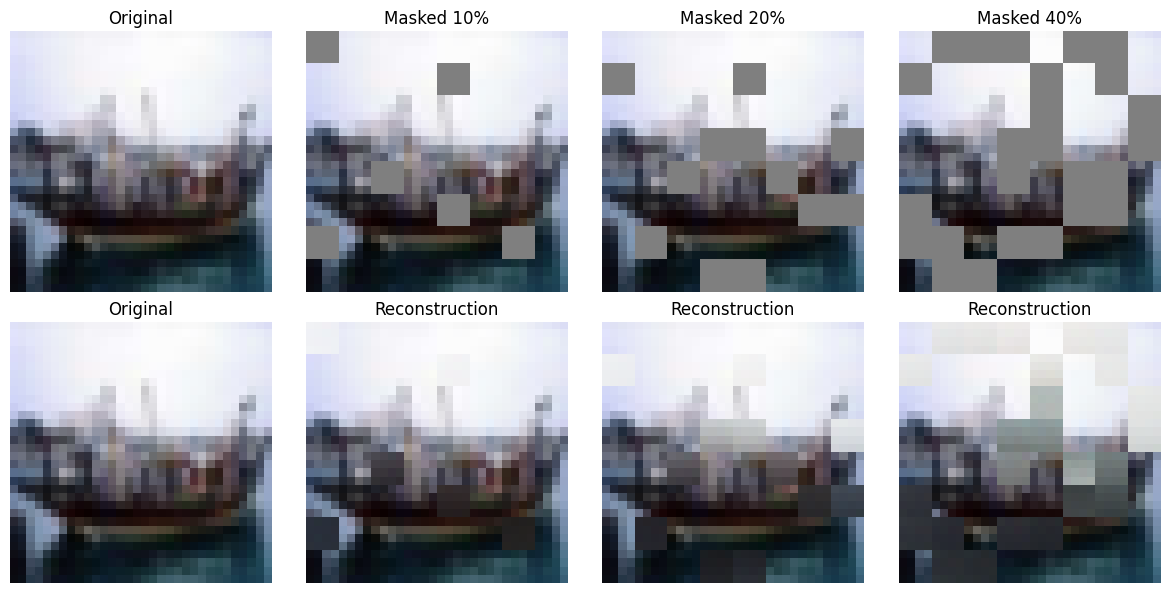

In [24]:
def make_masks_with_ratio(batch_size, ratio, seed=None):
    n_masked = int(NUM_PATCHES * ratio)
    scores = tf.random.uniform([batch_size, NUM_PATCHES], seed=seed)
    selected = tf.argsort(scores, axis=1)[:, :n_masked]
    return tf.reduce_any(
        tf.one_hot(
            selected, depth=NUM_PATCHES,
            on_value=True, off_value=False, dtype=tf.bool
        ),
        axis=1,
    )

one_image = tf.convert_to_tensor(x_test[18:19])
ratios = [0.10, 0.20, 0.40]

fig, axes = plt.subplots(2, len(ratios) + 1, figsize=(12, 6))
axes[0, 0].imshow(one_image[0])
axes[0, 0].set_title("Original")
axes[1, 0].imshow(one_image[0])
axes[1, 0].set_title("Original")

for col, ratio in enumerate(ratios, start=1):
    ratio_mask = make_masks_with_ratio(1, ratio, seed=100 + col)
    ratio_masked = apply_patch_mask(one_image, ratio_mask)
    ratio_recon = reconstruct_images(model, one_image, ratio_mask)
    axes[0, col].imshow(ratio_masked[0])
    axes[0, col].set_title(f"Masked {ratio:.0%}")
    axes[1, col].imshow(ratio_recon[0])
    axes[1, col].set_title("Reconstruction")

for ax in axes.flat:
    ax.axis("off")
plt.tight_layout()
plt.show()

### 10. 모델 저장 및 다시 불러오기

사용자 정의 `MaskToken` layer가 있으므로 Keras 형식으로 저장할 때 custom object를 함께 지정합니다. weight만 저장하는 방법은 구조가 단순하고 호환성이 좋습니다.

In [25]:
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
WEIGHTS_PATH = MODEL_DIR / "cifar10_tiny_masked_vit.weights.h5"

model.save_weights(WEIGHTS_PATH)
print("saved:", WEIGHTS_PATH.resolve())

# 다시 사용할 때:
# restored_model = build_masked_image_transformer()
# restored_model.load_weights(WEIGHTS_PATH)

saved: /content/models/cifar10_tiny_masked_vit.weights.h5


### 정리

- 이미지는 고정 크기 patch의 sequence로 바꾸면 Transformer가 처리할 수 있습니다.
- masked image reconstruction은 class label 없이 이미지 자체로 학습하는 self-supervised learning입니다.
- positional embedding은 각 patch가 이미지의 어느 위치에서 왔는지 알려 줍니다.
- loss를 masked patch에만 적용해야 모델이 가려진 영역을 복원하는 데 집중합니다.
- CIFAR-10은 32×32로 매우 작으므로 결과가 흐릿할 수 있으며, MSE는 여러 가능한 답의 평균에 가까운 색을 만드는 경향이 있습니다.

### 추가 실험

1. `PATCH_SIZE`를 2 또는 8로 바꾸면 token 수와 난이도가 어떻게 달라지는지 비교하세요.
2. `MASK_RATIO`를 0.25, 0.50, 0.75로 바꾸어 학습하세요.
3. Transformer `depth`, `embed_dim`, `num_heads`를 늘려 보세요.
4. MSE 대신 MAE loss를 사용해 복원 결과를 비교하세요.
5. 학습된 encoder를 CIFAR-10 분류 모델의 초기값으로 재사용해 보세요.